In [45]:
import numpy as np
import open3d as o3d
import open3d.ml.torch as ml3d
import open3d.ml as o3dml
import numpy as np
import yaml
from pathlib import Path
import matplotlib.pyplot as plt

In [46]:
print(torch.__version__)
print(torch.cuda.is_available())
print(np.__version__)
print(o3d.__version__)

2.2.2+cu121
True
1.24.4
0.19.0


In [47]:
class ScannetPrimitivesDet(o3dml.datasets.Scannet):

    def __init__(
        self,
        dataset_path: str,
        scannet_yaml_path: str,
        name: str = "ScannetPrimitivesDet",
        cache_dir: str = "./logs/cache",
        use_cache: bool = False,
        **kwargs,
    ):
        super().__init__(
            dataset_path=dataset_path,
            name=name,
            cache_dir=cache_dir,
            use_cache=use_cache,
            **kwargs,
        )

        self._scannet_yaml_path = scannet_yaml_path
        yaml_path = Path(scannet_yaml_path)
        if not yaml_path.exists():
            raise FileNotFoundError(f"Config file not found: {yaml_path}")

        with open(yaml_path, "r") as f:
            cfg = yaml.safe_load(f)

        self.classes = list(cfg["classes"])
        self.num_classes = len(self.classes)

        semantic_ids = cfg.get(
            "semantic_ids",
            list(range(len(self.classes))),
        )
        cat_ids = cfg.get(
            "cat_ids",
            list(range(len(self.classes))),
        )

        if len(semantic_ids) != self.num_classes:
            raise ValueError(
                f"Length of semantic_ids {len(semantic_ids)} "
                f"does not match number of classes {self.num_classes}"
            )

        if len(cat_ids) != self.num_classes:
            raise ValueError(
                f"Length of cat_ids {len(cat_ids)} "
                f"does not match number of classes {self.num_classes}"
            )

        self.semantic_ids = list(semantic_ids)
        self.cat_ids = np.array(cat_ids, dtype=np.int32)
        self.cat2label = {cat: i for i, cat in enumerate(self.classes)}

        ignored_label = cfg.get("ignored_label", -1)
        self.cat2label["ignored"] = ignored_label

        self.label2cat = {v: k for k, v in self.cat2label.items()}
        self.cat_ids2class = {
            raw_id: i for i, raw_id in enumerate(list(self.cat_ids))
        }

        self.label_to_names = self.get_label_to_names()

    def get_label_to_names(self):
        return self.label2cat

In [48]:
def compute_iou(box1, box2):
    """Вычисление IoU между двумя боксами"""
    # Простая 2D IoU (игнорируем высоту)
    x1_min, y1_min = box1.center[0] - box1.size[0]/2, box1.center[1] - box1.size[1]/2
    x1_max, y1_max = box1.center[0] + box1.size[0]/2, box1.center[1] + box1.size[1]/2
    
    x2_min, y2_min = box2.center[0] - box2.size[0]/2, box2.center[1] - box2.size[1]/2
    x2_max, y2_max = box2.center[0] + box2.size[0]/2, box2.center[1] + box2.size[1]/2
    
    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)
    
    if inter_xmax <= inter_xmin or inter_ymax <= inter_ymin:
        return 0.0
        
    inter_area = (inter_xmax - inter_xmin) * (inter_ymax - inter_ymin)
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    
    union_area = area1 + area2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

In [49]:
def compute_ap(predictions, ground_truths, iou_threshold=0.5):
    """Вычисление Average Precision для одного класса"""
    if not predictions or not ground_truths:
        return 0.0
    
    # Сортировка предсказаний по confidence
    predictions = sorted(predictions, key=lambda x: x['confidence'], reverse=True)
    
    tp = np.zeros(len(predictions))
    fp = np.zeros(len(predictions))
    gt_matched = [False] * len(ground_truths)
    
    for i, pred in enumerate(predictions):
        best_iou = 0.0
        best_gt_idx = -1
        
        for j, gt in enumerate(ground_truths):
            if gt_matched[j]:
                continue
            
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j
        
        if best_iou >= iou_threshold and best_gt_idx != -1:
            tp[i] = 1
            gt_matched[best_gt_idx] = True
        else:
            fp[i] = 1
    
    # Вычисление precision-recall
    fp_cumsum = np.cumsum(fp)
    tp_cumsum = np.cumsum(tp)
    
    recalls = tp_cumsum / len(ground_truths)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-8)
    
    # Вычисление AP через интерполяцию
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11
    
    return ap

In [50]:
def visualize_map(class_names, ap_scores):
    """Визуализация mAP по классам"""
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(class_names)), ap_scores, color='skyblue')
    plt.xlabel('Классы')
    plt.ylabel('Average Precision')
    plt.title(f'mAP по классам\nСредний mAP: {np.mean(ap_scores):.3f}')
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Добавление значений на столбцы
    for bar, score in zip(bars, ap_scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

In [51]:
# Основной код
ds = ScannetPrimitivesDet(
    dataset_path="data/scannet_primitives",
    scannet_yaml_path="scannet_primitives.yaml"
)
split = ds.get_split("train")
sample = split.get_data(0)
points = sample["point"].astype(np.float32)
boxes = sample['bounding_boxes']
label = sample["label"].astype(np.int32)

print(f"Points shape: {points.shape}")
print(f"Labels shape: {label.shape}")
names = ds.label_to_names
num_classes = int(max(names.keys())) + 1
rng = np.random.default_rng(0)
palette = rng.random((num_classes, 3))

Points shape: (18432, 3)
Labels shape: (18432,)


In [52]:
from open3d._ml3d.vis.boundingbox import BoundingBox3D

pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(points))
bbxs = [obj for obj in boxes]
ls = BoundingBox3D.create_lines(bbxs)
o3d.visualization.draw_geometries([pcd, ls])

cfg_file = 'pointpillars_primitives.yml'
cfg = o3dml.utils.Config.load_from_file(cfg_file)
model = ml3d.models.PointPillars(**cfg.model)
pipeline = ml3d.pipelines.ObjectDetection(
    model=model,
    dataset=ds,
    **cfg.pipeline
)

points_xyz = sample["point"].astype(np.float32)   # (N, 3)
data_infer = {
    "point": points_xyz
    }

In [ ]:
# Обучение модели 
print("\n" + "="*50)
print("1. ОБУЧЕНИЕ МОДЕЛИ")
print("="*50)

pipeline.run_train() 



1. ОБУЧЕНИЕ МОДЕЛИ
1 эпоха ~ 10 сек


training -  loss_cls: 0.338 loss_bbox: 1.378 loss_dir: 0.000 > loss: 1.716: 100%|██████████| 28/28 [00:04<00:00,  5.74it/s]
validation: 100%|██████████| 25/25 [00:00<00:00, 30.46it/s]
training -  loss_cls: 0.319 loss_bbox: 1.217 loss_dir: 0.000 > loss: 1.536: 100%|██████████| 28/28 [00:04<00:00,  5.71it/s]
validation: 100%|██████████| 25/25 [00:00<00:00, 31.09it/s]
training -  loss_cls: 0.328 loss_bbox: 1.216 loss_dir: 0.000 > loss: 1.544: 100%|██████████| 28/28 [00:04<00:00,  5.76it/s]
validation: 100%|██████████| 25/25 [00:00<00:00, 31.26it/s]
training -  loss_cls: 0.309 loss_bbox: 1.042 loss_dir: 0.000 > loss: 1.351: 100%|██████████| 28/28 [00:04<00:00,  5.88it/s]
validation: 100%|██████████| 25/25 [00:00<00:00, 32.99it/s]
training -  loss_cls: 0.296 loss_bbox: 1.053 loss_dir: 0.000 > loss: 1.350: 100%|██████████| 28/28 [00:04<00:00,  5.82it/s]
validation: 100%|██████████| 25/25 [00:00<00:00, 31.43it/s]
training -  loss_cls: 0.301 loss_bbox: 0.960 loss_dir: 0.000 > loss: 1.261: 100%


2. ИНФЕРЕНС ПОСЛЕ ОБУЧЕНИЯ


In [54]:
res = pipeline.run_inference(data_infer)  # Запускаем инференс после обучения

pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(points_xyz))

bbxs = res[0][0:5]
ls = BoundingBox3D.create_lines(bbxs)
o3d.visualization.draw_geometries([pcd, ls], window_name="Pred после обучения")

In [55]:
# Вычисление mAP
print("\n" + "="*50)
print("3. ВЫЧИСЛЕНИЕ mAP МЕТРИКИ (после обучения)")
print("="*50)

# Подготовка ground truth боксов
ground_truths_by_class = {}
for box in boxes:
    class_name = str(box.label_class)
    if class_name not in ground_truths_by_class:
        ground_truths_by_class[class_name] = []
    ground_truths_by_class[class_name].append({
        'box': box,
        'label': class_name
    })

# Подготовка предсказанных боксов (ПОСЛЕ ОБУЧЕНИЯ!)
predictions_by_class = {}
for box in res[0]:  # Все предсказанные боксы
    class_name = str(box.label_class)
    if class_name not in predictions_by_class:
        predictions_by_class[class_name] = []
    
    confidence = box.confidence if hasattr(box, 'confidence') else 1.0
    predictions_by_class[class_name].append({
        'box': box,
        'confidence': confidence,
        'label': class_name
    })


3. ВЫЧИСЛЕНИЕ mAP МЕТРИКИ (после обучения)



Класс           GT боксов    Pred боксов  AP        
--------------------------------------------------
background      0            0            0.0000    
box             4            6            0.7273    
sphere          2            7            1.0000    
cylinder        1            7            1.0000    
torus           1            7            0.0000    
cone            1            7            1.0000    
--------------------------------------------------
Средний mAP:                              0.6212    


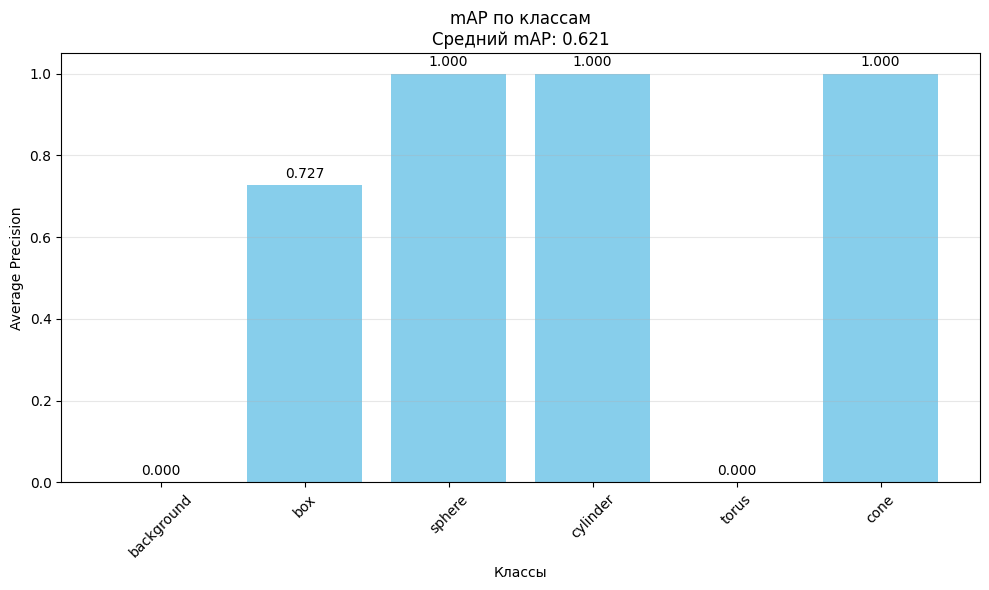


Готово! Обучение завершено, mAP вычислена.


In [ ]:
# Вычисление AP для каждого класса
class_names = ds.classes
ap_scores = []

print(f"\n{'Класс':<15} {'GT боксов':<12} {'Pred боксов':<12} {'AP':<10}")
print("-"*50)

for class_name in class_names:
    gt_boxes = ground_truths_by_class.get(class_name, [])
    pred_boxes = predictions_by_class.get(class_name, [])
    
    if gt_boxes and pred_boxes:
        # Преобразуем боксы в формат для вычисления IoU
        gt_formatted = [{'box': item['box']} for item in gt_boxes]
        pred_formatted = [{'box': item['box'], 'confidence': item['confidence']} for item in pred_boxes]
        
        ap = compute_ap(pred_formatted, gt_formatted, iou_threshold=0.5)
    else:
        ap = 0.0
    
    ap_scores.append(ap)
    print(f"{class_name:<15} {len(gt_boxes):<12} {len(pred_boxes):<12} {ap:<10.4f}")

# Вычисление среднего mAP
mean_ap = np.mean(ap_scores)
print("-"*50)
print(f"{'Средний mAP:':<15} {'':<12} {'':<12} {mean_ap:<10.4f}")
print("="*50)

# Визуализация mAP
visualize_map(class_names, ap_scores)